# MobileNetV2 Knowledge Distillation 

## Knowledge Distillation Overview

Knowledge Distillation (KD) is a technique where a smaller student model learns from a larger, better-performing teacher model.

**Key Idea:**
- The student (MobileNetV2) learns to mimic the teacher's (EfficientNet-B0) soft predictions
- Soft targets contain richer information about class relationships than hard labels
- Temperature parameter $T$ controls the softness of predictions


## Imports

In [9]:
import time
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
import torchvision.models as models

In [10]:

# CONFIG
data_path         = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"
teacher_ckpt_path = r"D:\DELL\Documents\deeplearning_proj\EfficientB0\efficientnet_b0_best.pth"
student_model_path = "mobilenetv2_kd_best.pth"
TRAIN             = True  

## Device Check

In [11]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

True
0
NVIDIA T1200 Laptop GPU
Using device: cuda


## Dataset Preparation

### 1. Transforms

Same ImageNet normalization and augmentations as baseline MobileNetV2.

In [12]:
def get_resisc45_transforms(img_size=224, augment=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]) if augment else transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_tf, val_tf

### 2. DataLoader Setup

In [13]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)

In [14]:
def get_dataloaders(data_root, img_size=224, batch_size=24):
    train_tf, val_tf = get_resisc45_transforms(img_size)

    base_dataset = datasets.ImageFolder(root=data_root)

    n_total = len(base_dataset)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val

    # Same seed as other models — identical train/val/test splits
    train_ds, val_ds, test_ds = random_split(
        base_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    train_ds = TransformSubset(train_ds, train_tf)
    val_ds   = TransformSubset(val_ds, val_tf)
    test_ds  = TransformSubset(test_ds, val_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )

    return train_loader, val_loader, test_loader

## Architecture Student (MobileNetV2) & Teacher (EfficientNet-B0)

**Student Model:** MobileNetV2 the lightweight model we want to train

**Teacher Model:** EfficientNet-B0 a pre-trained, more accurate model that guides the student

In [15]:
# load pretrained MobileNetV2(student) and modify classifier head for 45 classes
def build_mobilenetv2(num_classes: int = 45, dropout_p: float = 0.2) -> nn.Module:
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )

    return model

# load pretrained EfficientNet-B0(teacher) and modify classifier head for 45 classes
def build_efficientnet_b0(num_classes: int = 45, dropout_p: float = 0.3) -> nn.Module:
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model

# utility to count total and trainable parameters in a model
def count_params(model: nn.Module):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters  : {total:,}")
    print(f"Trainable params  : {trainable:,}")
    print(f"Model size (FP32) : {total * 4 / 1024**2:.2f} MB")

## Knowledge Distillation Loss

In [16]:
# Knowledge Distillation Loss combining student CE loss (learn ground truth labels) and teacher KL divergence (learn teacher soft targets)
class KDLoss(nn.Module):
 
    def __init__(self, alpha: float = 0.5, temperature: float = 4.0):
        super().__init__()
        self.alpha = alpha  # Weight for CE loss
        self.temperature = temperature  # Temperature for softening
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')

    def forward(self, student_logits, teacher_logits, labels):
        # Hard target loss (student learns from ground truth labels)
        ce = self.ce_loss(student_logits, labels)

        # Soft target loss (student learns from teacher predictions)
        # Temperature scaling makes predictions softer (more informative)
        student_soft = F.log_softmax(student_logits / self.temperature, dim=1)
        teacher_soft = F.softmax(teacher_logits / self.temperature, dim=1)
        kd = self.kl_loss(student_soft, teacher_soft)

        # Combined loss
        loss = self.alpha * ce + (1 - self.alpha) * (self.temperature ** 2) * kd

        return loss, ce, kd

## Training Functions

In [17]:
def train_one_epoch(
    student: nn.Module,
    teacher: nn.Module,
    loader: DataLoader,
    kd_criterion: KDLoss,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):
  
# Training loop with Knowledge Distillation. Teacher is frozen (evaluationmode), student is trained.
    student.train()
    teacher.eval()  # Teacher always in eval mode, never updated

    total_loss = 0.0
    total_ce = 0.0
    total_kd = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True, dtype=torch.float32)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass: get logits from both models
        student_logits = student(images)
        with torch.no_grad():
            teacher_logits = teacher(images)

        # Compute KD loss
        loss, ce, kd = kd_criterion(student_logits, teacher_logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_ce   += ce.item() * images.size(0)
        total_kd   += kd.item() * images.size(0)
        preds = student_logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return {
        "loss": total_loss / total,
        "ce_loss": total_ce / total,
        "kd_loss": total_kd / total,
        "acc": correct / total
    }

### Evaluate

In [18]:
@torch.no_grad()
def evaluate(
    student: nn.Module,
    teacher: nn.Module,
    loader: DataLoader,
    kd_criterion: KDLoss,
    device: torch.device,
):
# Evaluation using KD loss (for consistency with training).
    student.eval()
    teacher.eval()

    total_loss = 0.0
    total_ce = 0.0
    total_kd = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        student_logits = student(images)
        teacher_logits = teacher(images)

        loss, ce, kd = kd_criterion(student_logits, teacher_logits, labels)

        total_loss += loss.item() * images.size(0)
        total_ce   += ce.item() * images.size(0)
        total_kd   += kd.item() * images.size(0)
        preds = student_logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return {
        "loss": total_loss / total,
        "ce_loss": total_ce / total,
        "kd_loss": total_kd / total,
        "acc": correct / total
    }

### Full Training Loop with Knowledge Distillation

In [19]:
def train_with_kd(
    student: nn.Module,
    teacher: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    alpha: float = 0.5,
    temperature: float = 4.0,
    save_path: str = "mobilenetv2_kd_best.pth",
    device_str: str = "auto",
):
    # training loop with Knowledge Distillation, Student learns from both ground truth labels and teacher predictions.
    device = (
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if device_str == "auto"
        else torch.device(device_str)
    )

    print(f"Training on: {device}")
    print(f"Knowledge Distillation Parameters:")
    print(f"  - alpha (CE weight)    : {alpha}")
    print(f"  - temperature          : {temperature}")

    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()  # Teacher never trains

# loss function that combines CE and KD losses
    kd_criterion = KDLoss(alpha=alpha, temperature=temperature)

# Adam optimizer for student model
    optimizer = torch.optim.Adam(
        student.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
# Cosine annealing LR scheduler for smooth decay over epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

    best_val_acc = 0.0
    patience_ctr = 0
    patience = 5

    history = []

    for epoch in range(1, num_epochs + 1):

        t0 = time.time()

        train_stats = train_one_epoch(
            student, teacher, train_loader,
            kd_criterion, optimizer, device
        )

        val_stats = evaluate(
            student, teacher, val_loader,
            kd_criterion, device
        )

        scheduler.step()
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']

        print(
            f"Epoch {epoch:3d}/{num_epochs}  "
            f"Train Loss: {train_stats['loss']:.4f} | "
            f"Train Acc: {train_stats['acc']:.4f} | "
            f"Val Loss: {val_stats['loss']:.4f} | "
            f"Val Acc: {val_stats['acc']:.4f} | "
            f"LR: {lr_now:.2e} | "
            f"{elapsed:.1f}s"
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_ce_loss": train_stats["ce_loss"],
            "train_kd_loss": train_stats["kd_loss"],
            "train_acc": train_stats["acc"],
            "val_loss": val_stats["loss"],
            "val_ce_loss": val_stats["ce_loss"],
            "val_kd_loss": val_stats["kd_loss"],
            "val_acc": val_stats["acc"],
            "lr": lr_now,
        })

        if val_stats['acc'] > best_val_acc:

            best_val_acc = val_stats['acc']
            patience_ctr = 0

            torch.save({
                "epoch": epoch,
                "model_state": student.state_dict(),
                "val_acc": best_val_acc,
            }, save_path)

            print(f"  New best saved: {best_val_acc:.4f}")

        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(
                    f"\n Early stopping at epoch {epoch} "
                    f"(no improvement for {patience} epochs)"
                )
                break

    print(f"\nTraining complete. Best val acc: {best_val_acc:.4f}")
    return history

## Run — Training with Knowledge Distillation

In [ ]:

# CONFIG
TRAIN = True

# BUILD MODELS
print(" Student Model (MobileNetV2) ")
student = build_mobilenetv2(num_classes=45, dropout_p=0.2)
count_params(student)

print("\n Teacher Model (EfficientNet-B0) ")
teacher = build_efficientnet_b0(num_classes=45, dropout_p=0.3)
count_params(teacher)

# LOAD TEACHER WEIGHTS
if not os.path.exists(teacher_ckpt_path):
    raise FileNotFoundError(f"Teacher checkpoint not found: {teacher_ckpt_path}")

print(f"\n Loading teacher weights from: {teacher_ckpt_path}")
teacher_ckpt = torch.load(teacher_ckpt_path, map_location=device, weights_only=False)
teacher.load_state_dict(teacher_ckpt["model_state"])
teacher = teacher.to(device)
teacher.eval()  # Teacher is always in evaluation mode
print("Teacher model loaded and frozen")

# DATA
if TRAIN:
    train_loader, val_loader, test_loader = get_dataloaders(data_path)
else:
    _, _, test_loader = get_dataloaders(data_path)

# Sanity check
test_batch_img, test_batch_lbl = next(iter(test_loader))
test_batch_img = test_batch_img.to(device)
print(f"\nTest batch on device: {test_batch_img.device}")
print(f"Batch shape: {test_batch_img.shape}")

# Quick forward pass check
student_tmp = student.to(device)
teacher_tmp = teacher.to(device)
with torch.no_grad():
    s_out = student_tmp(test_batch_img)
    t_out = teacher_tmp(test_batch_img)
print(f"Student output shape: {s_out.shape}   (expected: [{test_batch_img.shape[0]}, 45])")
print(f"Teacher output shape: {t_out.shape}   (expected: [{test_batch_img.shape[0]}, 45])")

# TRAIN OR LOAD
if TRAIN:
    print("Starting Knowledge Distillation training...")

    history = train_with_kd(
        student, teacher,
        train_loader, val_loader,
        num_epochs=10,
        lr=1e-4,
        weight_decay=1e-4,
        alpha=0.5,          # 50% hard targets, 50% soft targets
        temperature=4.0,    # Higher = softer predictions = more information
        save_path=student_model_path
    )
    student.eval()
else:
    if not os.path.exists(student_model_path):
        raise FileNotFoundError(f"Student checkpoint not found: {student_model_path}")

    print(f"\nLoading trained student model from: {student_model_path}")
    student_ckpt = torch.load(student_model_path, map_location=device, weights_only=False)
    student.load_state_dict(student_ckpt["model_state"])
    student = student.to(device)
    student.eval()

print("\nBoth models ready ")

=== Student Model (MobileNetV2) ===
Total parameters  : 2,281,517
Trainable params  : 2,281,517
Model size (FP32) : 8.70 MB

=== Teacher Model (EfficientNet-B0) ===
Total parameters  : 4,065,193
Trainable params  : 4,065,193
Model size (FP32) : 15.51 MB

 Loading teacher weights from: D:\DELL\Documents\deeplearning_proj\EfficientB0\efficientnet_b0_best.pth
Teacher model loaded and frozen

Test batch on device: cuda:0
Batch shape: torch.Size([24, 3, 224, 224])
Student output shape: torch.Size([24, 45])   (expected: [24, 45])
Teacher output shape: torch.Size([24, 45])   (expected: [24, 45])

Starting Knowledge Distillation training...

Training on: cuda
Knowledge Distillation Parameters:
  - alpha (CE weight)    : 0.5
  - temperature          : 4.0
Epoch   1/10  Train Loss: 1.0417 | Train Acc: 0.7780 | Val Loss: 0.7043 | Val Acc: 0.8876 | LR: 9.76e-05 | 854.7s
  New best saved: 0.8876
Epoch   2/10  Train Loss: 0.7061 | Train Acc: 0.8978 | Val Loss: 0.6337 | Val Acc: 0.9124 | LR: 9.05e-05

## Evaluation (Model Metrics)

In [20]:
def print_model_metrics(model: nn.Module, model_name: str = "Model", img_size: int = 224):
    device = next(model.parameters()).device

    stats = summary(
        model,
        input_size=(1, 3, img_size, img_size),
        device=device,
        verbose=0,
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total_params * 4 / (1024 ** 2)

    print(f"  {model_name}")
    print(f"  Total parameters  : {total_params:,}")
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Model size (FP32) : {size_mb:.2f} MB")
    print(f"  Total FLOPs       : {stats.total_mult_adds / 1e9:.2f} GFLOPs")


In [22]:
# Load best checkpoint for final evaluation
student_ckpt = torch.load(student_model_path, weights_only=False)
student = build_mobilenetv2(num_classes=45)
student.load_state_dict(student_ckpt["model_state"])
student = student.to(device)
student.eval()
train_loader, val_loader, test_loader = get_dataloaders(data_path)

# Load teacher
if 'teacher' not in locals():
    teacher = build_efficientnet_b0(num_classes=45)
    teacher_ckpt = torch.load(teacher_ckpt_path, map_location=device, weights_only=False)
    teacher.load_state_dict(teacher_ckpt["model_state"])
    teacher = teacher.to(device)
    teacher.eval()

# Criterion for evaluation
kd_criterion = KDLoss(alpha=0.5, temperature=4.0)

# Test evaluation
test_stats = evaluate(student, teacher, test_loader, kd_criterion, device)

print("\n TEST RESULTS (with Knowledge Distillation) ")
print(f"Test Accuracy  : {test_stats['acc']:.4f}")
print(f"Test Loss      : {test_stats['loss']:.4f}")
print(f"  - CE Loss    : {test_stats['ce_loss']:.4f}")
print(f"  - KD Loss    : {test_stats['kd_loss']:.4f}")

print("\n MODEL METRICS (FP32) ")
print_model_metrics(student, "Student (MobileNetV2)")
print_model_metrics(teacher, "Teacher (EfficientNet-B0)")


 TEST RESULTS (with Knowledge Distillation) 
Test Accuracy  : 0.9496
Test Loss      : 0.4964
  - CE Loss    : 0.8626
  - KD Loss    : 0.0081

 MODEL METRICS (FP32) 
  Student (MobileNetV2)
  Total parameters  : 2,281,517
  Trainable params  : 2,281,517
  Model size (FP32) : 8.70 MB
  Total FLOPs       : 0.30 GFLOPs
  Teacher (EfficientNet-B0)
  Total parameters  : 4,065,193
  Trainable params  : 4,065,193
  Model size (FP32) : 15.51 MB
  Total FLOPs       : 0.38 GFLOPs


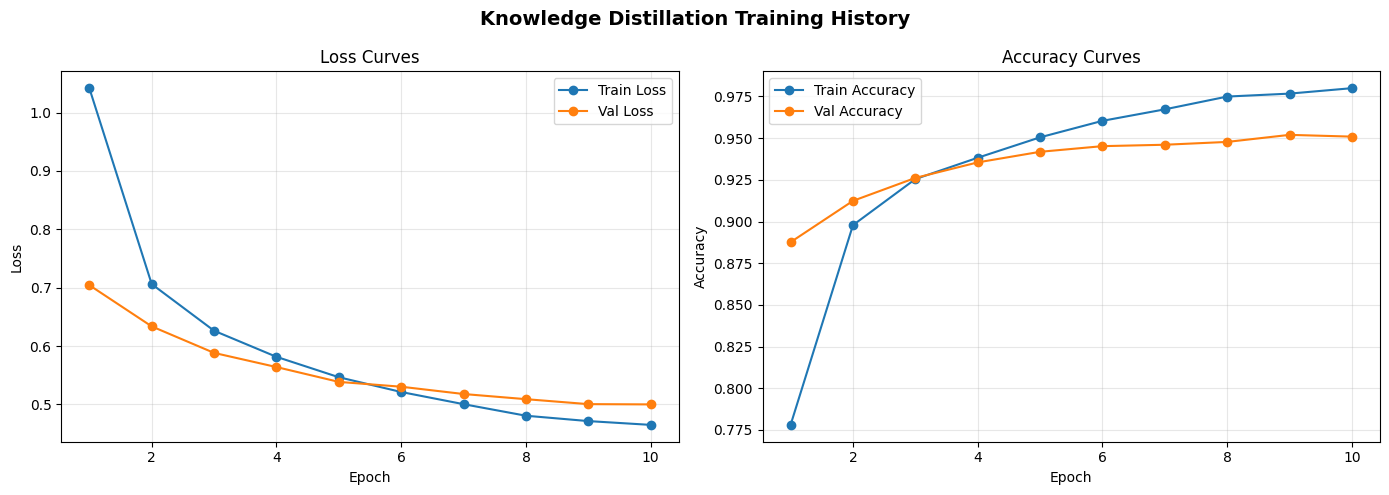

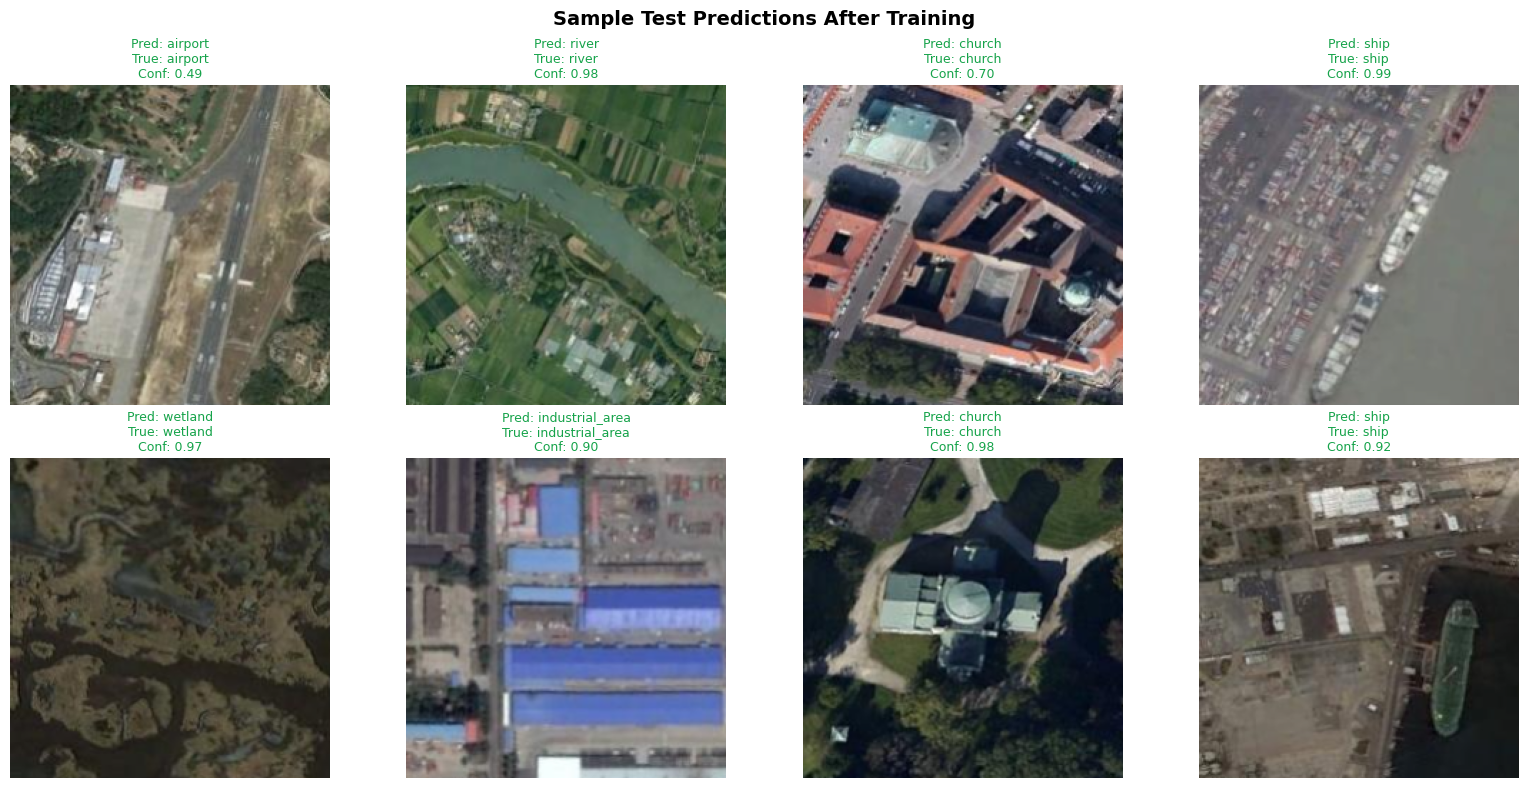


Final Test Accuracy: 0.9496
Final Test Loss    : 0.4964


In [18]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_history(history):
    if not history:
        print("No training history available to plot.")
        return

    epochs = [row["epoch"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row["val_loss"] for row in history]
    train_acc = [row["train_acc"] for row in history]
    val_acc = [row["val_acc"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_loss, marker="o", label="Train Loss")
    axes[0].plot(epochs, val_loss, marker="o", label="Val Loss")
    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_acc, marker="o", label="Train Accuracy")
    axes[1].plot(epochs, val_acc, marker="o", label="Val Accuracy")
    axes[1].set_title("Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.suptitle("Knowledge Distillation Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def denormalize_image(image_tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    image = image_tensor.cpu().numpy()
    image = std * image + mean
    image = np.clip(image, 0, 1)
    return np.transpose(image, (1, 2, 0))


def show_sample_predictions(model, loader, class_names, device, num_samples=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]

    with torch.no_grad():
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1).cpu()
        confidences = probabilities.max(dim=1).values.cpu()

    cols = min(4, num_samples)
    rows = int(np.ceil(num_samples / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for idx in range(num_samples):
        ax = axes[idx]
        ax.imshow(denormalize_image(images[idx]))
        true_name = class_names[int(labels[idx])]
        pred_name = class_names[int(predictions[idx])]
        is_correct = predictions[idx].item() == labels[idx].item()
        color = "#16a34a" if is_correct else "#dc2626"
        ax.set_title(
            f"Pred: {pred_name}\nTrue: {true_name}\nConf: {confidences[idx].item():.2f}",
            fontsize=9,
            color=color,
        )
        ax.axis("off")

    for idx in range(num_samples, len(axes)):
        axes[idx].axis("off")

    plt.suptitle("Sample Test Predictions After Training", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


if "history" in globals() and history:
    plot_training_history(history)

class_names = datasets.ImageFolder(root=data_path).classes
show_sample_predictions(student, test_loader, class_names, device, num_samples=8)

if "test_stats" in globals():
    print(f"\nFinal Test Accuracy: {test_stats['acc']:.4f}")
    print(f"Final Test Loss    : {test_stats['loss']:.4f}")

## Comparison: Baseline MobileNetV2 vs Knowledge Distillation

This section compares the normal MobileNetV2 checkpoint against the KD-trained MobileNetV2 student on the same test split.


=== BASELINE VS KD COMPARISON ===
Model                      Accuracy       Loss
----------------------------------------------
Baseline MobileNetV2         0.9534     0.2656
KD MobileNetV2               0.9496     0.2768


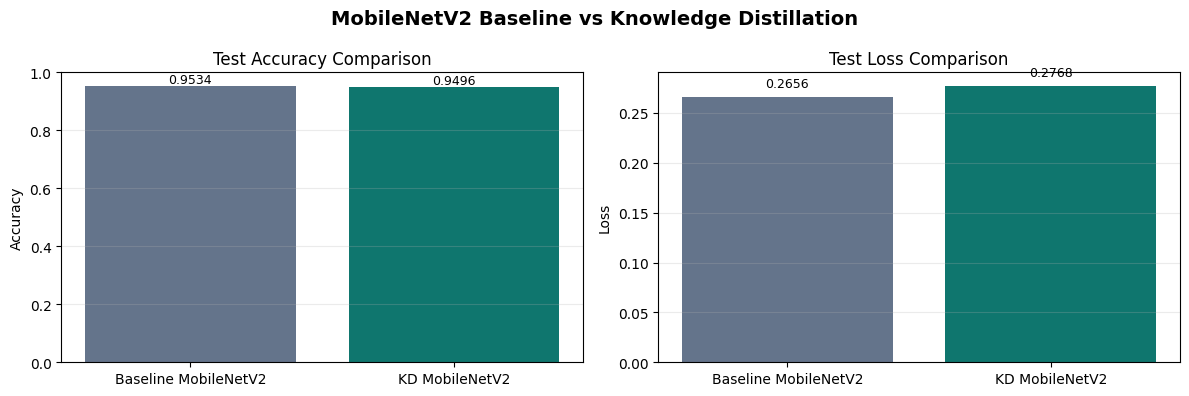

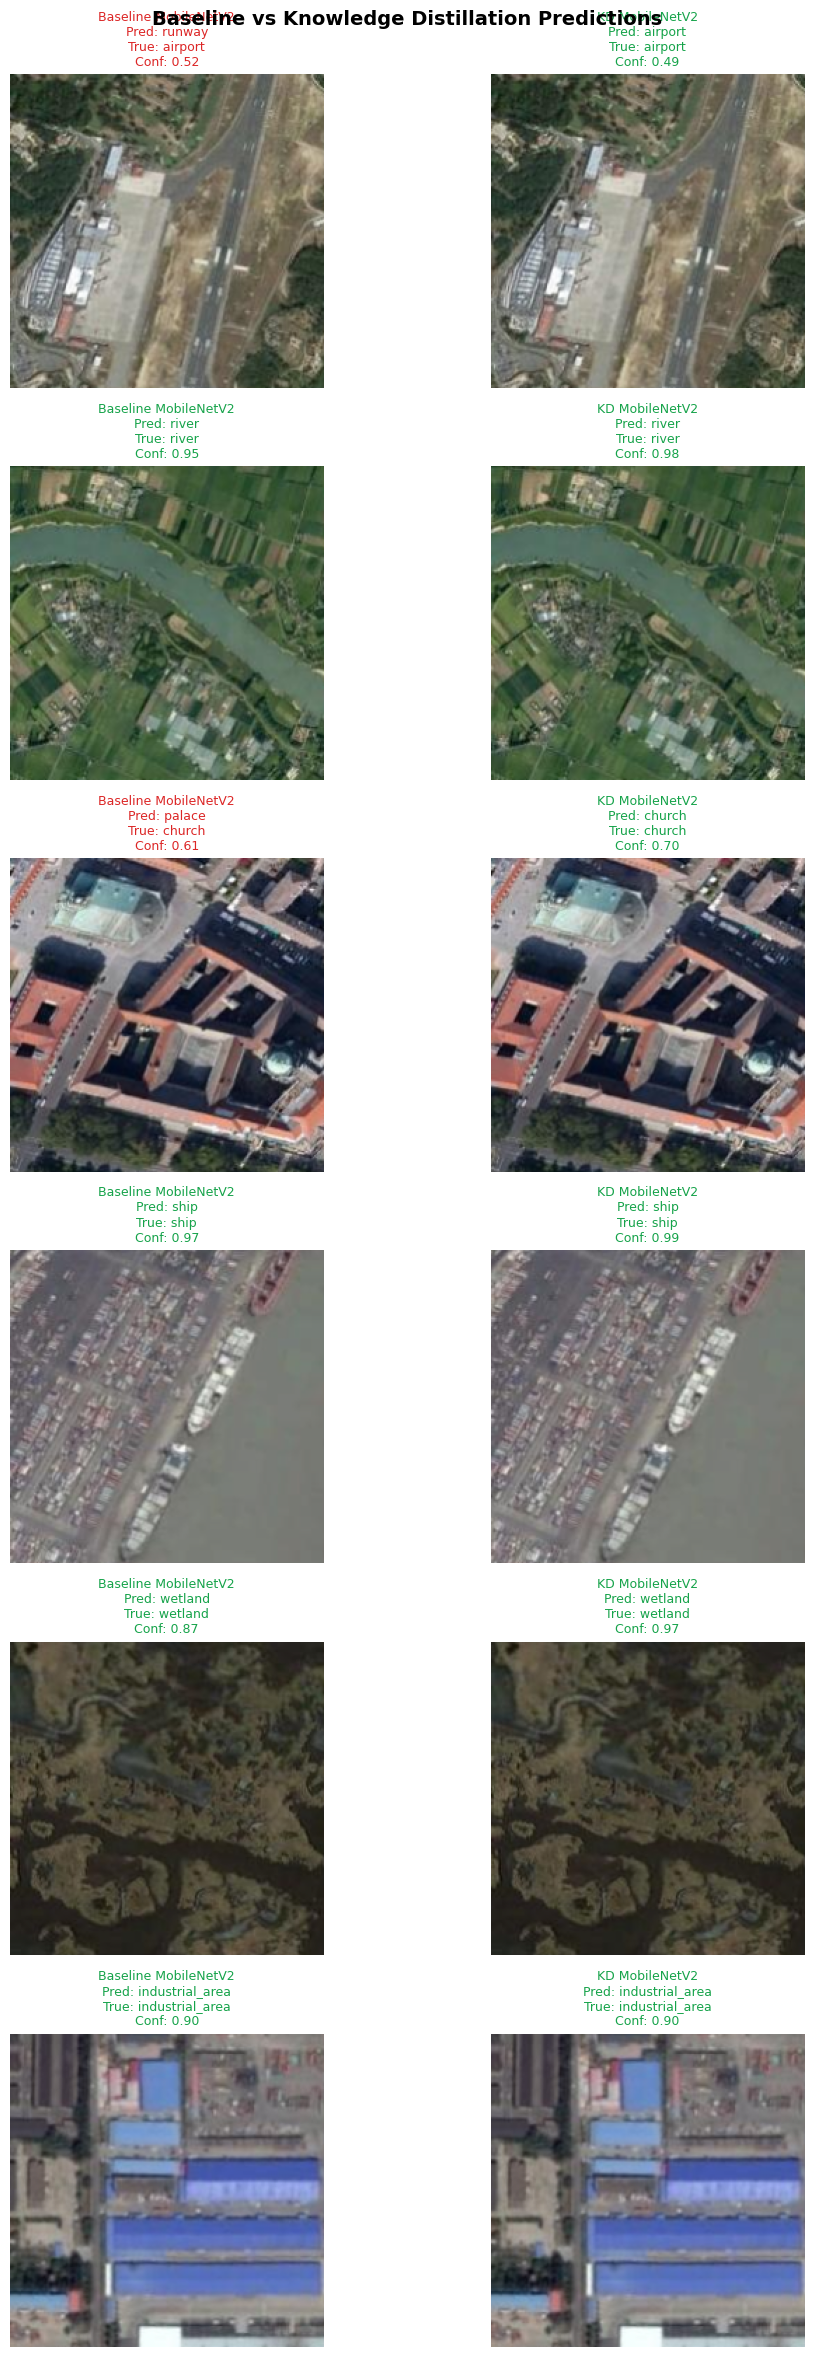


Accuracy gain from KD: -0.0038
Loss reduction from KD: -0.0112


In [19]:
from pathlib import Path


def evaluate_plain_model(model, loader, device):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return {"loss": total_loss / total, "acc": correct / total}


def load_mobilenet_from_checkpoint(checkpoint_path, device):
    model = build_mobilenetv2(num_classes=45)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()
    return model


def show_side_by_side_predictions(baseline_model, kd_model, loader, class_names, device, num_samples=6):
    images, labels = next(iter(loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]

    with torch.no_grad():
        baseline_probs = torch.softmax(baseline_model(images), dim=1)
        kd_probs = torch.softmax(kd_model(images), dim=1)

    baseline_preds = baseline_probs.argmax(dim=1).cpu()
    kd_preds = kd_probs.argmax(dim=1).cpu()
    baseline_conf = baseline_probs.max(dim=1).values.cpu()
    kd_conf = kd_probs.max(dim=1).values.cpu()

    fig, axes = plt.subplots(num_samples, 2, figsize=(11, 4 * num_samples))
    if num_samples == 1:
        axes = np.array([axes])

    for idx in range(num_samples):
        true_name = class_names[int(labels[idx])]
        base_name = class_names[int(baseline_preds[idx])]
        kd_name = class_names[int(kd_preds[idx])]
        base_ok = baseline_preds[idx].item() == labels[idx].item()
        kd_ok = kd_preds[idx].item() == labels[idx].item()

        axes[idx, 0].imshow(denormalize_image(images[idx]))
        axes[idx, 0].set_title(
            f"Baseline MobileNetV2\nPred: {base_name}\nTrue: {true_name}\nConf: {baseline_conf[idx].item():.2f}",
            fontsize=9,
            color="#16a34a" if base_ok else "#dc2626",
        )
        axes[idx, 0].axis("off")

        axes[idx, 1].imshow(denormalize_image(images[idx]))
        axes[idx, 1].set_title(
            f"KD MobileNetV2\nPred: {kd_name}\nTrue: {true_name}\nConf: {kd_conf[idx].item():.2f}",
            fontsize=9,
            color="#16a34a" if kd_ok else "#dc2626",
        )
        axes[idx, 1].axis("off")

    plt.suptitle("Baseline vs Knowledge Distillation Predictions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


baseline_ckpt_path = r"D:\DELL\Documents\deeplearning_proj\MobileNet\mobilenetv2_best.pth"
kd_ckpt_path = r"D:\DELL\Documents\deeplearning_proj\MobileNet\mobilenetv2_kd_best.pth"

if not os.path.exists(baseline_ckpt_path):
    raise FileNotFoundError(f"Baseline MobileNet checkpoint not found: {baseline_ckpt_path}")
if not os.path.exists(kd_ckpt_path):
    raise FileNotFoundError(f"KD MobileNet checkpoint not found: {kd_ckpt_path}")

baseline_model = load_mobilenet_from_checkpoint(baseline_ckpt_path, device)
kd_model = load_mobilenet_from_checkpoint(kd_ckpt_path, device)

baseline_stats = evaluate_plain_model(baseline_model, test_loader, device)
kd_stats = evaluate_plain_model(kd_model, test_loader, device)

comparison_rows = [
    ["Baseline MobileNetV2", baseline_stats["acc"], baseline_stats["loss"]],
    ["KD MobileNetV2", kd_stats["acc"], kd_stats["loss"]],
]

print("\n=== BASELINE VS KD COMPARISON ===")
print(f"{'Model':<24} {'Accuracy':>10} {'Loss':>10}")
print("-" * 46)
for name, acc_value, loss_value in comparison_rows:
    print(f"{name:<24} {acc_value:>10.4f} {loss_value:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_labels = [row[0] for row in comparison_rows]
accuracy_values = [row[1] for row in comparison_rows]
loss_values = [row[2] for row in comparison_rows]
bar_colors = ["#64748b", "#0f766e"]

axes[0].bar(model_labels, accuracy_values, color=bar_colors)
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", alpha=0.25)
for idx, value in enumerate(accuracy_values):
    axes[0].text(idx, value + 0.01, f"{value:.4f}", ha="center", fontsize=9)

axes[1].bar(model_labels, loss_values, color=bar_colors)
axes[1].set_title("Test Loss Comparison")
axes[1].set_ylabel("Loss")
axes[1].grid(axis="y", alpha=0.25)
for idx, value in enumerate(loss_values):
    axes[1].text(idx, value + 0.01, f"{value:.4f}", ha="center", fontsize=9)

plt.suptitle("MobileNetV2 Baseline vs Knowledge Distillation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

class_names = datasets.ImageFolder(root=data_path).classes
show_side_by_side_predictions(baseline_model, kd_model, test_loader, class_names, device, num_samples=6)

print(f"\nAccuracy gain from KD: {kd_stats['acc'] - baseline_stats['acc']:.4f}")
print(f"Loss reduction from KD: {baseline_stats['loss'] - kd_stats['loss']:.4f}")